## Functions 

In [75]:
# Function to create a new database with user input and error handling

import psycopg2
from psycopg2 import sql
import tkinter as tk
from tkinter import simpledialog, messagebox
import logging

# Configure logging
logging.basicConfig(
    filename="database_operations.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

def create_database():

    try:
        # Create hidden root window
        root = tk.Tk()
        root.withdraw()

        # Dialogue box
        db_name = simpledialog.askstring(
            "Database Creation",
            "Enter database name:",
            initialvalue="TEST"
        )

        if not db_name:
            messagebox.showinfo("Cancelled", "Database creation cancelled.")
            logging.info("User cancelled database creation.")
            return

        conn = psycopg2.connect(
            host="localhost",
            database="postgres",
            user="postgres",
            password="admin",
            port=5432
        )

        conn.autocommit = True
        cursor = conn.cursor()

        # Check if database exists
        cursor.execute(
            "SELECT 1 FROM pg_database WHERE datname = %s;",
            (db_name,)
        )

        exists = cursor.fetchone()

        if exists:
            messagebox.showwarning(
                "Database Exists",
                f"Database '{db_name}' already exists."
            )
            logging.warning(f"Database '{db_name}' already exists.")
        else:
            cursor.execute(
                sql.SQL("CREATE DATABASE {}").format(
                    sql.Identifier(db_name)
                )
            )
            messagebox.showinfo(
                "Success",
                f"Database '{db_name}' created successfully."
            )
            logging.info(f"Database '{db_name}' created successfully.")

        cursor.close()
        conn.close()

    except Exception as e:
        logging.error(f"Error creating database: {e}")
        messagebox.showerror("Error", f"An error occurred:\n{e}")

In [76]:
# Function to drop an existing database with user input and error handling

import psycopg2
from psycopg2 import sql
import tkinter as tk
from tkinter import simpledialog, messagebox
import logging

# Use the same logging file used in the create_database function
logging.basicConfig(
    filename="database_operations.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

def drop_database():

    try:
        root = tk.Tk()
        root.withdraw()

        # Ask user which database to drop
        db_name = simpledialog.askstring(
            "Drop Database",
            "Enter database name to drop:",
            initialvalue="TEST"
        )

        if not db_name:
            messagebox.showinfo("Cancelled", "Database drop cancelled.")
            logging.info("User cancelled database drop.")
            return

        conn = psycopg2.connect(
            host="localhost",
            database="postgres",
            user="postgres",
            password="admin",
            port=5432
        )

        conn.autocommit = True
        cursor = conn.cursor()

        # Check if database exists
        cursor.execute(
            "SELECT 1 FROM pg_database WHERE datname = %s;",
            (db_name,)
        )

        exists = cursor.fetchone()

        if not exists:
            messagebox.showwarning(
                "Database Not Found",
                f"Database '{db_name}' does not exist."
            )
            logging.warning(f"Attempted to drop non-existing database '{db_name}'.")
        else:

            # Terminate existing connections
            cursor.execute("""
                SELECT pg_terminate_backend(pid)
                FROM pg_stat_activity
                WHERE datname = %s
                AND pid <> pg_backend_pid();
            """, (db_name,))

            # Drop database safely
            cursor.execute(
                sql.SQL("DROP DATABASE {}").format(
                    sql.Identifier(db_name)
                )
            )

            messagebox.showinfo(
                "Success",
                f"Database '{db_name}' dropped successfully."
            )
            logging.info(f"Database '{db_name}' dropped successfully.")

        cursor.close()
        conn.close()

    except Exception as e:
        logging.error(f"Error dropping database: {e}")
        messagebox.showerror("Error", f"An error occurred:\n{e}")

In [77]:
# A dialogue to select TSV files

import tkinter as tk
from tkinter import filedialog

def select_tsv_files():
    root = tk.Tk()
    root.withdraw()  # hide main window

    file_paths = filedialog.askopenfilenames(
        title="Select TSV Files",
        filetypes=[("TSV files", "*.tsv")]
    )

    return list(file_paths)

# Function to read the first line of a TSV file and return column names

import csv

def get_columns(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        reader = csv.reader(f, delimiter="\t")
        header = next(reader)
    return header

# Function to check if a table exists in the database

def table_exists(cursor, table_name):

    cursor.execute(
        """
        SELECT EXISTS (
            SELECT 1
            FROM information_schema.tables
            WHERE table_schema = 'public'
            AND table_name = %s
        )
        """,
        (table_name,)
    )

    return cursor.fetchone()[0]

# Function to generate a CREATE TABLE SQL statement based on column names

def create_table_sql(table_name, columns):

    column_defs = []

    for col in columns:
        col = (
            col.replace("-", "_")
               .replace(" ", "_")
               .replace(".", "_")
        )

        column_defs.append(f'"{col}" TEXT')

    columns_sql = ",\n".join(column_defs)

    return f"""
    CREATE TABLE IF NOT EXISTS "{table_name}" (
        {columns_sql}
    );
    """

In [ ]:
# Function to connect to the database with user input and error handling

def connect_db():

    try:
        # Create hidden root window
        root = tk.Tk()
        root.withdraw()

        # Dialogue box
        db_name = simpledialog.askstring(
            "Database Creation",
            "Enter database name:",
            initialvalue="TEST"
        )

        if not db_name:
            messagebox.showinfo("Cancelled", "Database creation cancelled.")
            logging.info("User cancelled database creation.")
            return
        
        conn = psycopg2.connect(
            host="localhost",
            database=db_name,
            user="postgres",
            password="admin",
            port=5432
        )

        cursor = conn.cursor()

        logging.info("Database connection established")

        return conn, cursor

    except Exception as e:

        logging.error(f"Database connection failed: {e}")
        raise

## Workflow

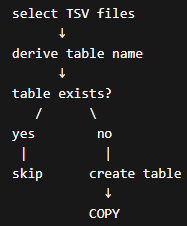

In [79]:
import os
import logging
from psycopg2 import sql

def load_tsv_to_postgres():

    try:

        create_database()
        conn, cursor = connect_db()

        files = select_tsv_files()

        print("Selected files:")
        logging.info("TSV files selected")

        for f in files:
            print(f)
            logging.info(f"File selected: {f}")

        for file_path in files:

            table_name = (
                os.path.basename(file_path)
                .replace(".tsv", "")
                .replace(".", "_")
                .replace(" ", "_")
            )

            logging.info(f"Processing file: {file_path}")

            try:

                # ---- CHECK TABLE EXISTENCE ----
                if table_exists(cursor, table_name):

                    print(f"Skipping {table_name} (already exists)")
                    logging.warning(f"Skipped load: table '{table_name}' already exists")

                    continue

                # ---- CREATE TABLE ----
                columns = get_columns(file_path)
                create_sql = create_table_sql(table_name, columns)

                cursor.execute(create_sql)

                logging.info(f"Table created: {table_name}")

                # ---- COPY DATA ----
                with open(file_path, "r", encoding="utf-8") as f:

                    cursor.copy_expert(
                        sql.SQL("""
                            COPY {} FROM STDIN
                            WITH (
                                FORMAT TEXT,
                                DELIMITER E'\\t',
                                HEADER TRUE,
                                NULL '\\N'
                            )
                        """).format(sql.Identifier(table_name)).as_string(conn),
                        f
                    )

                conn.commit()

                print(f"Loaded {table_name}")
                logging.info(f"Loaded table successfully: {table_name}")

            except Exception as table_error:

                conn.rollback()

                logging.error(
                    f"Error loading {table_name}: {table_error}"
                )

                print(f"Error loading {table_name}: {table_error}")

        cursor.close()
        conn.close()

        logging.info("TSV ingestion completed")

    except Exception as e:

        logging.critical(f"Fatal loader error: {e}")
        print(f"Fatal error: {e}")

In [81]:
if __name__ == "__main__":
    load_tsv_to_postgres()

Selected files:
D:/Datasets/IMDB-18March2026/name.basics.tsv
D:/Datasets/IMDB-18March2026/title.akas.tsv
D:/Datasets/IMDB-18March2026/title.basics.tsv
D:/Datasets/IMDB-18March2026/title.crew.tsv
D:/Datasets/IMDB-18March2026/title.episode.tsv
D:/Datasets/IMDB-18March2026/title.principals.tsv
D:/Datasets/IMDB-18March2026/title.ratings.tsv
Skipping name_basics (already exists)
Skipping title_akas (already exists)
Skipping title_basics (already exists)
Skipping title_crew (already exists)
Skipping title_episode (already exists)
Skipping title_principals (already exists)
Skipping title_ratings (already exists)
